In [5]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
from scipy.stats import dunnett
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
import plot_of_experiment_data as ped


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [21]:
# for screening result 

# tarsal result 
fpath = f'{os.getcwd()}/data/tarsal_screening.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_tarsal = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_tarsal[s] = df
    
fpath = f'{os.getcwd()}/data/labial_screening.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_labial = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_labial[s] = df

,group,comparison,U,p_raw,asterisk
0,SS48944 FMIn,Control vs. SS48944 FMIn,24.0,0.005577,**
1,SS47744 roundup,Control vs. SS47744 roundup,24.0,0.005577,**
2,SSS46885 TH-VUM,Control vs. SSS46885 TH-VUM,23.5,0.007437,**
3,SS37122 usnea,Control vs. SS37122 usnea,17.5,0.134923,ns
4,SS48947 clavicle,Control vs. SS48947 clavicle,17.0,0.136127,ns
5,SS31320 bract,Control vs. SS31320 bract,9.0,0.788593,ns
6,SS50091 rattle,Control vs. SS50091 rattle,8.5,0.819345,ns
7,SS47080 G2N-1,Control vs. SS47080 G2N-1,4.0,0.975024,ns


,group,comparison,U,p_raw,asterisk,p_adj
0,SS48944 FMIn,Control vs. SS48944 FMIn,24.0,0.005577,*,0.044613
1,SS47744 roundup,Control vs. SS47744 roundup,24.0,0.005577,*,0.044613
2,SSS46885 TH-VUM,Control vs. SSS46885 TH-VUM,23.5,0.007437,*,0.044621
3,SS37122 usnea,Control vs. SS37122 usnea,17.5,0.134923,ns,0.674614
4,SS48947 clavicle,Control vs. SS48947 clavicle,17.0,0.136127,ns,0.674614
5,SS31320 bract,Control vs. SS31320 bract,9.0,0.788593,ns,1.000000
6,SS50091 rattle,Control vs. SS50091 rattle,8.5,0.819345,ns,1.000000
7,SS47080 G2N-1,Control vs. SS47080 G2N-1,4.0,0.975024,ns,1.000000


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

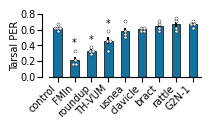

In [25]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# ======================================
# 공통 레이아웃
# ======================================

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32

BAR_H = 1.0

fontsize = 7
lp = 1

colors = ['#13739E', '#952B7E']

bar_spacing = 0.15
bar_width = 0.075


# ======================================
# 데이터 정리
# ======================================

cols = [
    'control',
    'SS48944 FMIn',
    'SS47744 roundup',
    'SSS46885 TH-VUM',
    'SS37122 usnea',
    'SS48947 clavicle',
    'SS31320 bract',
    'SS50091 rattle',
    'SS47080 G2N-1'
]


mean_mat = pd.DataFrame(
    index=cols,
    columns=['sugar'],
    dtype=float
)

std_mat = pd.DataFrame(
    index=cols,
    columns=['sugar'],
    dtype=float
)


mean_mat['sugar'] = (
    data_df_tarsal['sugar'][cols]
    .mean(axis=0)
)

std_mat['sugar'] = ped.std_err(
    data_df_tarsal['sugar'][cols]
)


# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(2, BAR_H),
    constrained_layout=False
)


# ======================================
# Bar + scatter
# ======================================

xloc = ped.draw_bar_with_points(
    ax=ax,

    conditions=cols,
    groups=['sugar'],

    get_values=lambda cond, group:
        data_df_tarsal[group][cond].values,

    get_mean=lambda cond, group:
        mean_mat.loc[cond, group],

    get_err=lambda cond, group:
        std_mat.loc[cond, group],

    bar_width=bar_width,
    bar_spacing=bar_spacing,

    colors=[colors[0]],

    edgecolor='black',
    linewidth=.5,

    capsize=0,

    point_facecolor='white',
    point_edgecolor='black',
    point_lw=.3,
    point_size=5,
    point_alpha=.9
)


# ======================================
# Statistics
#
# Mann–Whitney U
# H1: control > genotype
# ======================================
df_stat = data_df_tarsal['sugar'][cols]

control = df_stat['control'].dropna()

results = []

for col in cols:

    if col == 'control':
        continue

    group = df_stat[col].dropna()

    stat, p = mannwhitneyu(
        control,
        group,
        alternative='greater',
        method='auto'
    )

    results.append({
        'group': col,
        'comparison': 'Control vs. ' + col,
        'U': stat,
        'p_raw': p
    })



results = pd.DataFrame(results)
results['asterisk'] =  results['p_raw'].apply(ped.pval_to_asterisks)
display(results)



# # ======================================
# # Holm correction
# # ======================================

results['p_adj'] = multipletests(
    results['p_raw'],
    method='holm'
)[1]

results['asterisk'] = results['p_adj'].apply(
    ped.pval_to_asterisks
)

display(results)


# ======================================
# Significance marks
# ======================================

max_vals = (
    data_df_tarsal['sugar'][cols]
    .max(axis=0)
)


for i, c in enumerate(cols[1:], start=1):

    ast = results.loc[
        results['group'] == c,
        'asterisk'
    ].iloc[0]

    if ast != 'ns':

        ypos = max_vals[c] + .03

        ax.text(
            xloc[i],
            ypos,
            ast,
            fontsize=7,
            ha='center',
            va='bottom'
        )


# ======================================
# Axis formatting
# ======================================

xlabel = [
    x.split(" ")[-1]
    for x in cols
]

# xlabel[0] = '+/UAS-Kir2.1'


ax.set_xticks(
    xloc,
    xlabel,
    rotation=45,
    ha='right'
)


ax.set_yticks(
    np.arange(0, 1, .2)
)


ax.set_ylabel(
    'Tarsal PER',
    labelpad=lp
)


ax.set_ylim([
    0,
    0.8
])


ax.set_xlim(
    -bar_spacing / 2,
    xloc[-1] + bar_spacing / 2
)


ax.spines[['top', 'right']].set_visible(False)


ax.spines['left'].set_position(
    ('outward', 5)
)


ax.tick_params(
    pad=1
)


ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5


# ======================================
# Layout
# ======================================

fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)


# ======================================
# Save
# ======================================

# plt.savefig(
#     'figures/kir2.1_tarsal_PER_N=8.svg'
# )

,group,comparison,U,p_raw,asterisk,p_adj
0,SS50091 rattle,Control vs. SS50091 rattle,24.0,0.005577,*,0.043568
1,SS37122 usnea,Control vs. SS37122 usnea,24.0,0.005446,*,0.043568
2,SS47744 roundup,Control vs. SS47744 roundup,24.0,0.005446,*,0.043568
3,SS48944 FMIn,Control vs. SS48944 FMIn,24.0,0.005446,*,0.043568
4,SS48947 clavicle,Control vs. SS48947 clavicle,24.0,0.005577,*,0.043568
5,SSS46885 TH-VUM,Control vs. SSS46885 TH-VUM,24.0,0.005577,*,0.043568
6,SS31320 bract,Control vs. SS31320 bract,24.0,0.005709,*,0.043568
7,SS47080 G2N-1,Control vs. SS47080 G2N-1,24.0,0.005446,*,0.043568


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

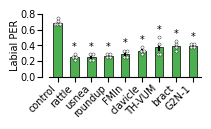

In [26]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# ======================================
# 공통 레이아웃
# ======================================

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32

BAR_H = 1.0

fontsize = 7
lp = 1

colors = ['#4CAF50','#E68613']

bar_spacing = 0.15
bar_width = 0.075


# ======================================
# 데이터 정리
# ======================================

cols = [
    'control',
    'SS50091 rattle',
    'SS37122 usnea',
    'SS47744 roundup',
    'SS48944 FMIn',
    'SS48947 clavicle',
    'SSS46885 TH-VUM',
    'SS31320 bract',
    'SS47080 G2N-1'
]


mean_mat = pd.DataFrame(
    index=cols,
    columns=['sugar'],
    dtype=float
)

std_mat = pd.DataFrame(
    index=cols,
    columns=['sugar'],
    dtype=float
)


mean_mat['sugar'] = (
    data_df_labial['sugar'][cols]
    .mean(axis=0)
)

std_mat['sugar'] = ped.std_err(
    data_df_labial['sugar'][cols]
)


# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(2, BAR_H),
    constrained_layout=False
)


# ======================================
# Bar + scatter
# ======================================

xloc = ped.draw_bar_with_points(
    ax=ax,

    conditions=cols,
    groups=['sugar'],

    get_values=lambda cond, group:
        data_df_labial[group][cond].values,

    get_mean=lambda cond, group:
        mean_mat.loc[cond, group],

    get_err=lambda cond, group:
        std_mat.loc[cond, group],

    bar_width=bar_width,
    bar_spacing=bar_spacing,

    colors=[colors[0]],

    edgecolor='black',
    linewidth=.5,

    capsize=0,

    point_facecolor='white',
    point_edgecolor='black',
    point_lw=.3,
    point_size=5,
    point_alpha=.9
)


# ======================================
# Statistics
#
# Mann–Whitney U
# H1: control > genotype
# ======================================

df_stat = data_df_labial['sugar'][cols]

control = df_stat['control'].dropna()

results = []

for col in cols:

    if col == 'control':
        continue

    group = df_stat[col].dropna()

    stat, p = mannwhitneyu(
        control,
        group,
        alternative='greater',
        method='auto'
    )

    results.append({
        'group': col,
        'comparison': 'Control vs. ' + col,
        'U': stat,
        'p_raw': p
    })



results = pd.DataFrame(results)
results['asterisk'] =  results['p_raw'].apply(ped.pval_to_asterisks)

# # ======================================
# # Holm correction
# # ======================================

results['p_adj'] = multipletests(
    results['p_raw'],
    method='holm'
)[1]

results['asterisk'] = results['p_adj'].apply(
    ped.pval_to_asterisks
)

display(results)


# ======================================
# Significance marks
# ======================================

max_vals = (
    data_df_labial['sugar'][cols]
    .max(axis=0)
)


for i, c in enumerate(cols[1:], start=1):

    ast = results.loc[
        results['group'] == c,
        'asterisk'
    ].iloc[0]

    if ast != 'ns':

        ypos = max_vals[c] + .03

        ax.text(
            xloc[i],
            ypos,
            ast,
            fontsize=7,
            ha='center',
            va='bottom'
        )


# ======================================
# Axis formatting
# ======================================

xlabel = [
    x.split(" ")[-1]
    for x in cols
]

# xlabel[0] = '+/UAS-Kir2.1'


ax.set_xticks(
    xloc,
    xlabel,
    rotation=45,
    ha='right'
)


ax.set_yticks(
    np.arange(0, 1, .2)
)


ax.set_ylabel(
    'Labial PER',
    labelpad=lp
)


ax.set_ylim([
    0,
    0.8
])


ax.set_xlim(
    -bar_spacing / 2,
    xloc[-1] + bar_spacing / 2
)


ax.spines[['top', 'right']].set_visible(False)

ax.spines['left'].set_position(
    ('outward', 5)
)

ax.tick_params(
    pad=1
)

ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5


# ======================================
# Layout
# ======================================

fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)


# ======================================
# Save
# ======================================

# plt.savefig(
#     'figures/kir2.1_labial_PER_N=8.svg'
# )